### Гипотеза №1

**Нулевая гипотеза ($H_0$):** Клиенты в разных географических регионах (Франция, Испания, Германия) имеют одинаковую долю оттока.

**Альтернативная гипотеза ($H_1$):** География влияет на уровень оттока

* Предпосылки: место проживания клиентов имеет свой вклад в причину ухода или продолжение пользованием услугами банка. Например, некоторым регионам может предоставляться ряд акций, недоступных для других жителей.

* Критерий проверки: критерий независимости Хи-квадрат

In [ ]:
contingency_table = pd.crosstab(df['Geography'], df['Exited'])

In [ ]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Статистика Хи-квадрат: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Статистика Хи-квадрат: 301.2553
P-value: 0.0000


In [ ]:
print("Таблица сопряженности:")
contingency_table

Таблица сопряженности:


Exited,0,1
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


In [ ]:
print("Ожидаемые частоты:")
pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)

Ожидаемые частоты:


Exited,0,1
Geography,,
France,3992.6482,1021.3518
Germany,1997.9167,511.0833
Spain,1972.4351,504.5649


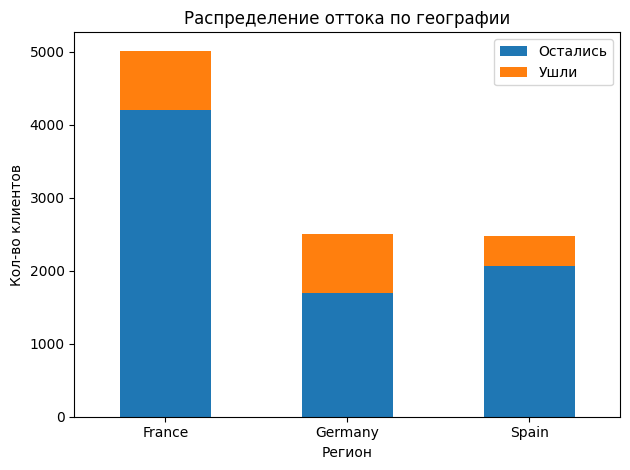

In [ ]:
contingency_table.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])
plt.title('Распределение оттока по географии')
plt.xlabel('Регион')
plt.ylabel('Кол-во клиентов')
plt.legend(['Остались', 'Ушли'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df.pivot_table(values='Exited', index='Geography', aggfunc='mean') * 100

,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


In [ ]:
alpha = 0.05
if p_value < alpha:
    print("Отвергаем нулевую гипотезу (H0). Есть основания полагать, что география влияет на уровень оттока.")
else:
    print("Не удается отклонить нулевую гипотезу (H0). Нет оснований говорить, что география влияет на уровень оттока.")

Отвергаем нулевую гипотезу (H0). Есть основания полагать, что география влияет на уровень оттока.


### Выводы

* Показатели оттока клиентов существенно различаются в странах: например, в Германии самый высокий уровень оттока (814/2509 ≈ 32,4%) по сравнению с Францией (810/5014 ≈ 16,2%) и Испанией (413/2477 ≈ 16,7%), как видно из таблицы непредвиденных расходов.

* Это наглядно видно на `bar chart'е`: большая доля оттока характерна для Германии по сравнению с другими регионами.

* Есть основания полагать, что банк сосредоточен больше на своих Французских клиентах.

### Гипотеза №2

**Нулевая гипотеза ($H_0$):** Средняя зарплата у ушедших и оставшихся клиентов одинаковая

**Альтернаятивная гипотеза ($H_1$):** Средняя зарплата у ушедших и оставшихся клиентов различается.

* Предпосылки: некоторые банки стремятся поощрять более платежеспособных клиентов, которые хранят бо́льшую часть своих средств/накоплений в этих банках.

* Критерий проверки: t-тест независимых выборок

In [ ]:
churned = df[df['Exited'] == 1]['EstimatedSalary']
retained = df[df['Exited'] == 0]['EstimatedSalary']

In [ ]:
t_stat, p_value = stats.ttest_ind(churned, retained, equal_var=True)

In [ ]:
mean_churned = churned.mean()
mean_retained = retained.mean()
std_churned = churned.std()
std_retained = retained.std()

In [ ]:
print(f"Статистика Стьюдента: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Статистика Стьюдента: 1.2097
p-value: 0.2264


In [ ]:
print(f"Средняя з/п ушедших клиентов: {mean_churned:.2f}")
print(f"Средняя з/п оставшихся клиентов: {mean_retained:.2f}")

Средняя з/п ушедших клиентов: 101465.68
Средняя з/п оставшихся клиентов: 99738.39


<ipython-input-72-a3709fd06294>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='EstimatedSalary', data=df, palette=['#1f77b4', '#ff7f0e'])


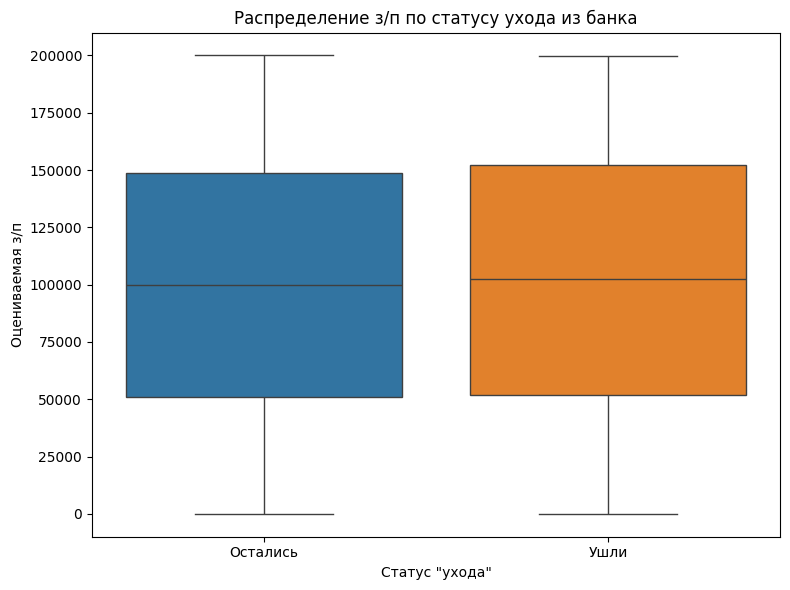

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Exited', y='EstimatedSalary', data=df, palette=['#1f77b4', '#ff7f0e'])
plt.title('Распределение з/п по статусу ухода из банка')
plt.xlabel('Статус "ухода"')
plt.ylabel('Оцениваемая з/п')
plt.xticks([0, 1], ['Остались', 'Ушли'])
plt.tight_layout()

plt.show()

In [ ]:
alpha = 0.05
if p_value < alpha:
    print("Отвергаем нулевую гипотезу (H0). Есть признаки того, что средняя зарплата ушедних и оставшихся клиентов различается.")
else:
    print("Не удается отклонить нулевую гипотезу (H0). Нет причин утверждать, что средняя зарплата ушедних и оставшихся клиентов отличается.")

Не удается отклонить нулевую гипотезу (H0). Нет причин утверждать, что средняя зарплата ушедних и оставшихся клиентов отличается.


### Выводы

* Средние зарплаты ушедних и оставшихся клиентов существенно не различаются.

* Средние зарплаты (101465.68 у ушедних и 99738.39 оставшихся) довольно близки, а высокое значение p предполагает, что любая наблюдаемая разница может быть вызвана случайными колебаниями.

* Можно сделать вывод, что средняя зарплата не является причиной прекращения пользованием услугами банка.